In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Student Social Media And Mental Health Impact.csv")

In [3]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


In [5]:
df.isnull().sum()

Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

In [6]:
df.duplicated().sum()

2

In [7]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

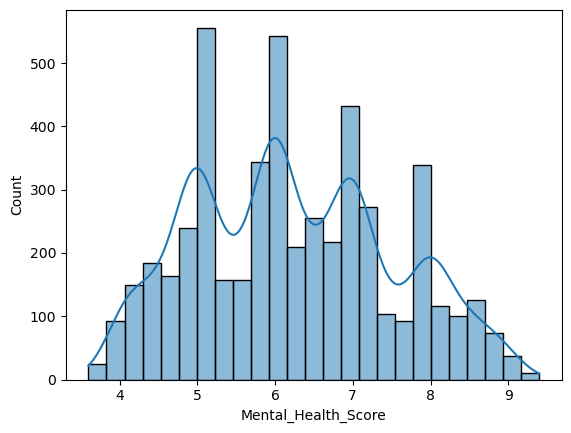

In [8]:
#EDA
# histogram is used to determine shape, sknewness and distribution of data 
sns.histplot(df['Mental_Health_Score'], kde=True)

<Axes: >

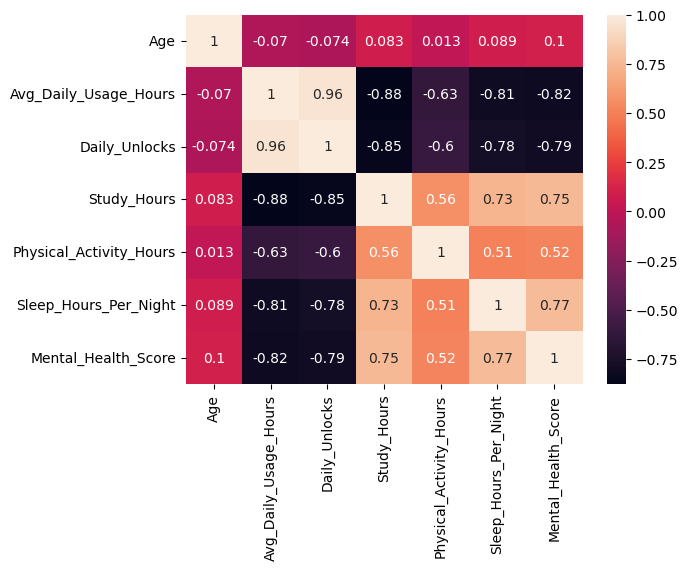

In [9]:
sns.heatmap(df.select_dtypes(exclude=['object']).corr(), annot=True)

In [10]:
df['Stress_Level'].unique()

array(['Medium', 'Low', 'Very High', 'High'], dtype=object)

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

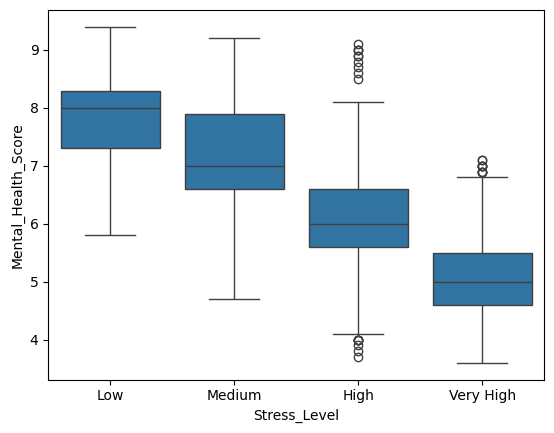

In [11]:
order = ['Low', 'Medium', 'High', 'Very High']
sns.boxplot(x='Stress_Level', y='Mental_Health_Score', data=df, order = order)

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Mental_Health_Score'>

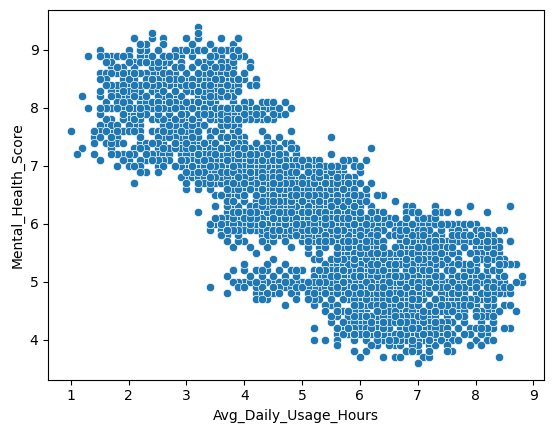

In [12]:
sns.scatterplot(y=df['Mental_Health_Score'], x=df['Avg_Daily_Usage_Hours'])

In [13]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='object')

<Axes: xlabel='Sleep_Hours_Per_Night', ylabel='Mental_Health_Score'>

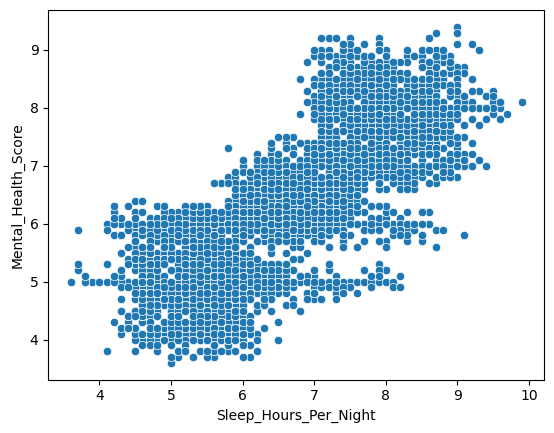

In [14]:
sns.scatterplot(x=df['Sleep_Hours_Per_Night'], y=df['Mental_Health_Score'])

<Axes: xlabel='Physical_Activity_Hours', ylabel='Mental_Health_Score'>

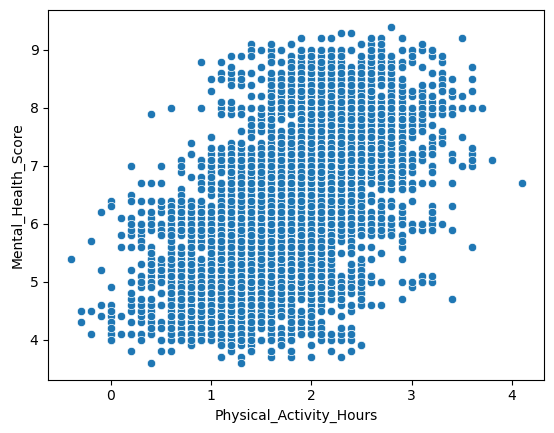

In [15]:
sns.scatterplot(x=df['Physical_Activity_Hours'], y=df['Mental_Health_Score'])

<Axes: xlabel='Study_Hours', ylabel='Mental_Health_Score'>

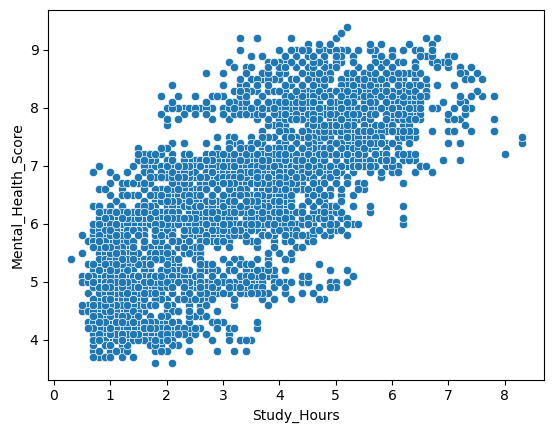

In [16]:
sns.scatterplot(x=df['Study_Hours'], y=df['Mental_Health_Score'])

<Axes: xlabel='Most_Used_Platform', ylabel='count'>

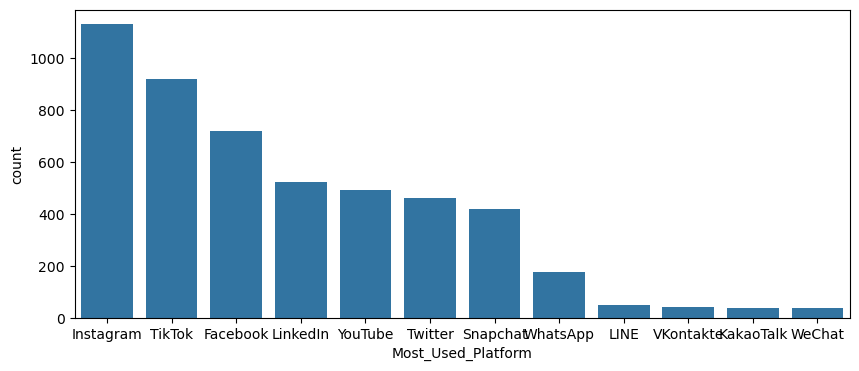

In [17]:
plt.figure(figsize=(10,4))
top_platfrom = df['Most_Used_Platform'].value_counts()
sns.countplot(x=df['Most_Used_Platform'], order= top_platfrom.index)

**Outliers**

In [18]:
num_feature= df.select_dtypes(include='number')
Q1=num_feature.quantile(0.25)
Q3 = num_feature.quantile(0.75)
IQR=Q3-Q1
lower_bound= Q1-1.5*IQR 
higher_bound= Q3+1.5*IQR

outliers = (num_feature<lower_bound) | (num_feature> higher_bound)
outliers.sum()

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64

In [19]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [20]:
df=df.drop_duplicates()
df

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,18,Female,Other,High School,YouTube,Education,1.9,89,6.1,2.2,7.9,Low,7.9
4996,18,Female,Other,High School,YouTube,Education,6.6,216,2.3,1.8,6.0,Very High,4.7
4997,19,Female,India,Undergraduate,LinkedIn,Education,3.8,151,5.4,1.4,7.5,Medium,7.0
4998,18,Male,Other,High School,Instagram,Entertainment,3.8,119,4.0,1.5,6.4,Medium,6.7


In [21]:
df['Physical_Activity_Hours']=df['Physical_Activity_Hours'].clip(lower=0)
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000
mean,20.822129,5.078491,171.455582,3.008403,1.751160,6.634654,6.231152
std,1.736774,1.654097,42.859829,1.636831,0.667282,1.221561,1.278476
min,18.000000,1.000000,62.000000,0.300000,0.000000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.000000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [22]:
num_col = df.select_dtypes(include='number')
num_col.skew()
#-0.5 to +0.5 good
#-0.75 to +0.75 slighlty skewed (moderate)
# beyond ned transformation

Age                        0.155008
Avg_Daily_Usage_Hours      0.005575
Daily_Unlocks              0.002309
Study_Hours                0.436125
Physical_Activity_Hours    0.053288
Sleep_Hours_Per_Night      0.123919
Mental_Health_Score        0.207086
dtype: float64

<Axes: xlabel='Study_Hours', ylabel='Count'>

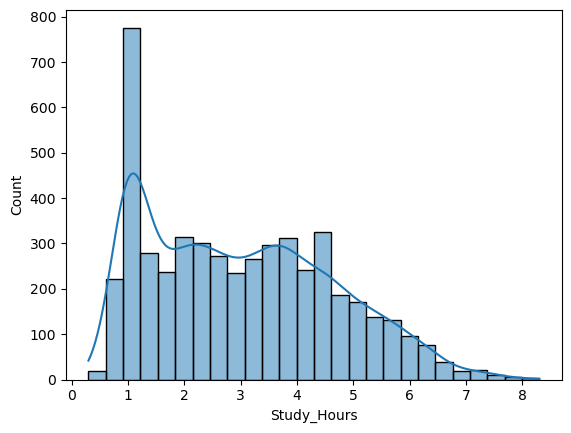

In [23]:
sns.histplot(df["Study_Hours"], kde = True)

In [24]:
top_country= df['Country'].value_counts().head(10)
top_country 

Country
Other        1879
India         389
USA           354
Canada        230
Australia     198
UK            185
Germany       136
Turkey         94
Mexico         94
France         87
Name: count, dtype: int64

In [25]:
def group_country(country):
    if country in top_country:
        return country
    else:
        return 'Other' 

In [26]:
df['group_country']=df['Country'].apply(group_country)

In [27]:
df['group_country'].value_counts()

group_country
Other        3231
India         389
USA           354
Canada        230
Australia     198
UK            185
Germany       136
Mexico         94
Turkey         94
France         87
Name: count, dtype: int64

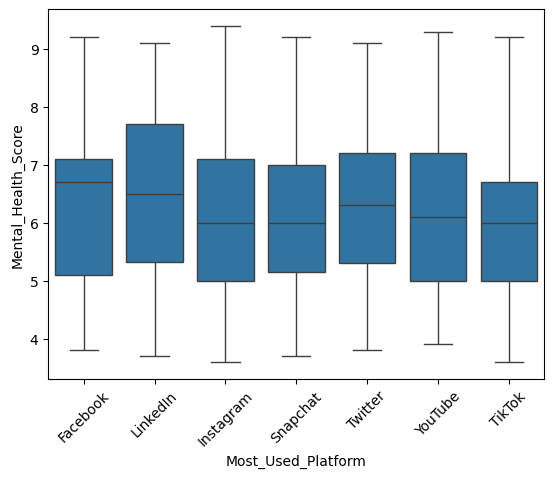

In [28]:
# sns.scatterplot(x=df["Most_Used_Platform"].value_counts()[:5].index, y=df["Mental_Health_Score"])

top_platforms = df['Most_Used_Platform'].value_counts().head(7).index

sns.boxplot(
    data=df[df['Most_Used_Platform'].isin(top_platforms)],
    x='Most_Used_Platform',
    y='Mental_Health_Score'
)
plt.xticks(rotation=45)
plt.show()

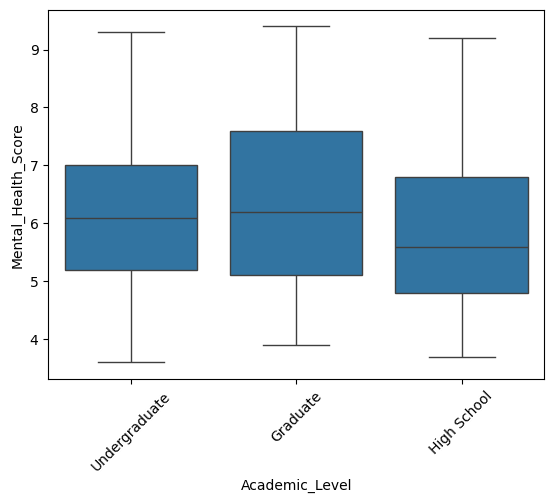

In [35]:
# sns.scatterplot(x=df["Most_Used_Platform"].value_counts()[:5].index, y=df["Mental_Health_Score"])

top_platforms = df['Academic_Level'].value_counts().head(7).index

sns.boxplot(
    data=df[df['Academic_Level'].isin(top_platforms)],
    x='Academic_Level',
    y='Mental_Health_Score'
)
plt.xticks(rotation=45)
plt.show()

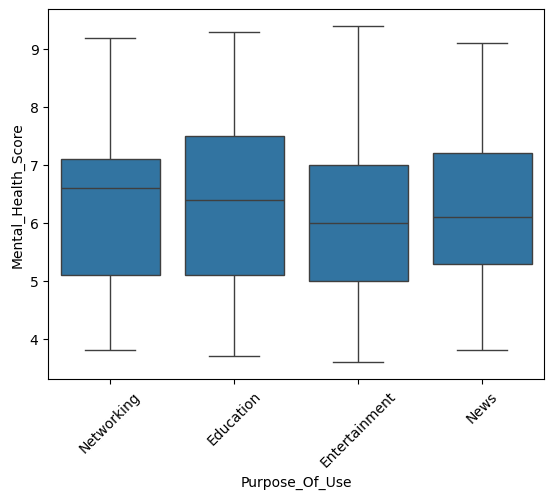

In [36]:
# sns.scatterplot(x=df["Most_Used_Platform"].value_counts()[:5].index, y=df["Mental_Health_Score"])

top_platforms = df['Purpose_Of_Use'].value_counts().head(7).index

sns.boxplot(
    data=df[df['Purpose_Of_Use'].isin(top_platforms)],
    x='Purpose_Of_Use',
    y='Mental_Health_Score'
)
plt.xticks(rotation=45)
plt.show()

In [ ]:

other_col = ['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score']

In [34]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score,group_country
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8,Other
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6,Other
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0,Canada
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3,Other
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4,Other


In [37]:
skew_col = ['Study_hours'] 

ordinal_col= ['Stress_Level']
onehot_col= ['group_country','Purpose_Of_Use', 'Most_Used_Platform','Gender','Academic_Level']

normal_col= ['Age', 'Avg_Daily_Usage_Hours','Daily_Unlocks', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',]

In [39]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
skew_pipe = Pipeline(steps=[
    ('log_transform', FunctionTransformer(np.log1p)),
    ('scale', StandardScaler()), 
])

ordinal_pipe= Pipeline(steps=[
    ('encode', OrdinalEncoder(categories=[['Low', 'Medium', 'High', 'Very High']]))   
])

onehot_pipe= Pipeline(steps=[
    ('encode', OneHotEncoder())
])

normal_pipe =Pipeline(steps=[('scaling', StandardScaler())])


ColumnTransformer(transformers=[
    ('skew', skew_pipe, skew_col),
    ('ordinal', ordinal_pipe, ordinal_col),
    ('onehot', onehot_pipe, onehot_col),
    ('normal', normal_pipe, normal_col)
])

ColumnTransformer(transformers=[('skew',
                                 Pipeline(steps=[('log_transform',
                                                  FunctionTransformer(func=<ufunc 'log1p'>)),
                                                 ('scale', StandardScaler())]),
                                 ['Study_hours']),
                                ('ordinal',
                                 Pipeline(steps=[('encode',
                                                  OrdinalEncoder(categories=[['Low',
                                                                              'Medium',
                                                                              'High',
                                                                              'Very '
                                                                              'High']]))]),
                                 ['Stress_Level']),
                                ('onehot',
                                 Pipeline(steps=[('encode', OneHotEncoder())]),
                                 ['group_country', 'Purpose_Of_Use',
                                  'Most_Used_Platform', 'Gender',
                                  'Academic_Level']),
                                ('normal',
                                 Pipeline(steps=[('scaling',
                                                  StandardScaler())]),
                                 ['Age', 'Avg_Daily_Usage_Hours',
                                  'Daily_Unlocks', 'Physical_Activity_Hours',
                                  'Sleep_Hours_Per_Night'])])

In [46]:
from sklearn.model_selection import train_test_split
x=df.drop(['Mental_Health_Score','Country'], axis=1)
y=df['Mental_Health_Score']

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.30, random_state=42)